In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# Le notebook est pensé pour être lancé depuis le dossier `exemples/`.
# Ce bloc rend aussi les imports robustes si le répertoire courant est la racine du projet.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "exemples" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lib.cea_lib.data_loader import data_preprocessing, load_RTCEA

/home/chapuissamuel/Documents/code/RT-Diffusion/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Modèle de diffusion conditionnelle sur coefficients ondelettes 1D

Objectif du notebook : générer des signaux 1D de taille `32` avec une cascade ondelette.

Chaque signal est décomposé en ondelettes de Haar (`db1`) à trois niveaux :

$$x \rightarrow (Ca_3, Ch_3, Ch_2, Ch_1).$$

La génération est factorisée ainsi :

$$p(Ca_3)\,p(Ch_3\mid Ca_3)\,p(Ch_2\mid Ca_2)\,p(Ch_1\mid Ca_1).$$

Points importants :

- `Ca3` est le prior basse fréquence et n'est pas conditionné.
- `Ch3`, `Ch2`, `Ch1` sont des détails haute fréquence conditionnés par l'approximation basse fréquence correspondante.
- `T_non_conditione` contrôle uniquement la diffusion de `Ca3`.
- `T` ou `T_conditionne` contrôle les modèles conditionnés et dépend du seuil `SNR_THRESHOLD`.

# Chargement du dataset RT-CEA

On charge un dataset 2D RT-CEA, puis on le prétraite en images `32 x 32`.
Pour rester dans un modèle 1D, chaque ligne horizontale d'une image devient un signal de longueur `SIGNAL_SIZE = 32`.

Les labels physiques chargés depuis le fichier HDF5 sont conservés comme métadonnées éventuelles, mais ne sont pas utilisés par le modèle de diffusion.

In [2]:
# -----------------------------
# Configuration générale
# -----------------------------
REQUESTED_SIGNAL_COUNT = 50_000
SIGNAL_SIZE = 32
DATA_FILE = PROJECT_ROOT / "data" / "RTCEA_bimode.hdf5"

MODEL_DIR = CURRENT_DIR / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)

FORCE_RETRAIN = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Chargement et prétraitement 2D
# -----------------------------
# Chaque image 32x32 fournit 32 lignes, donc 32 signaux 1D.
image_count = REQUESTED_SIGNAL_COUNT // SIGNAL_SIZE

data_raw, labels_raw = load_RTCEA(DATA_FILE)

try:
    data_norm, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=SIGNAL_SIZE,
    )
except ImportError as exc:
    # Fallback si OpenCV n'est pas disponible.
    # On garde le crop/mask de data_preprocessing, puis on redimensionne avec PyTorch.
    if "OpenCV" not in str(exc):
        raise
    data_cropped, metadata_labels = data_preprocessing(
        data_raw,
        labels_raw,
        resize=-1,
    )
    data_tensor = torch.as_tensor(data_cropped, dtype=torch.float32)[:, None]
    data_norm = F.interpolate(
        data_tensor,
        size=(SIGNAL_SIZE, SIGNAL_SIZE),
        mode="bilinear",
        align_corners=False,
    )[:, 0].numpy()

if data_norm.shape[0] == 0:
    raise ValueError("data_preprocessing n'a retourné aucune image. Vérifier le fichier et les critères de crop.")


# -----------------------------
# Passage 2D -> collection de signaux 1D
# -----------------------------
profile_images = data_norm[:image_count]
profiles = profile_images.reshape(-1, SIGNAL_SIZE)[:REQUESTED_SIGNAL_COUNT]

# Normalisation globale : utile car le bruit DDPM est gaussien standard.
dataset = torch.as_tensor(profiles, dtype=torch.float32)
signal_mean = dataset.mean()
signal_std = dataset.std().clamp_min(1e-8)
dataset = (dataset - signal_mean) / signal_std

signal_grid = torch.linspace(0, 1, SIGNAL_SIZE)
actual_signal_count = dataset.shape[0]

print("data_raw.shape       =", data_raw.shape)
print("data_norm.shape      =", data_norm.shape)
print("profile_images.shape =", profile_images.shape)
print("dataset.shape        =", dataset.shape)
print("mean/std             =", dataset.mean().item(), dataset.std().item())
print("DEVICE               =", DEVICE)

data_raw.shape       = (1978, 512, 256)
data_norm.shape      = (1445, 32, 32)
profile_images.shape = (1445, 32, 32)
dataset.shape        = torch.Size([46240, 32])
mean/std             = -3.3659095066695954e-08 1.0
DEVICE               = cpu


In [3]:
# Optionnel : pour changer le type de profil 1D, remplacer l'extraction par lignes ci-dessus
# par des colonnes, une moyenne verticale, ou une coupe choisie physiquement.


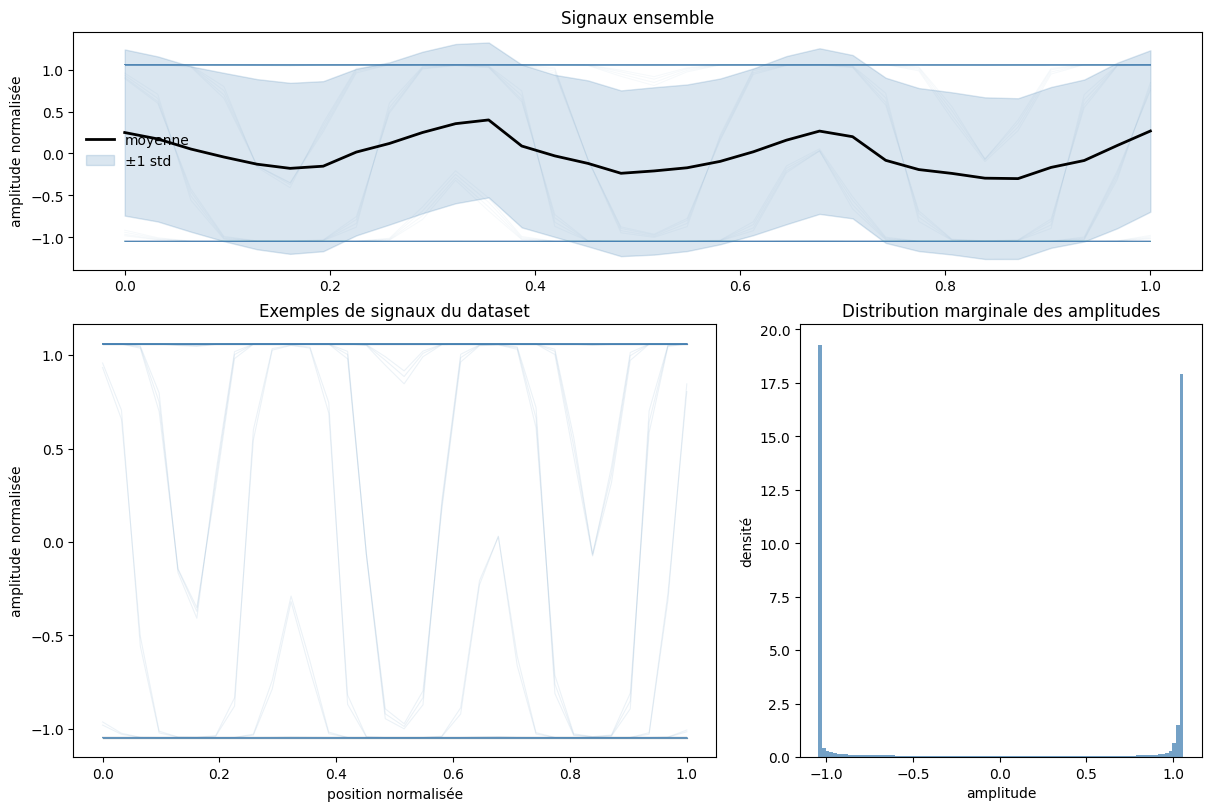

In [4]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.1, 1.0, 1.0],
    width_ratios=[1.6, 1.0],
)

ax_all = fig.add_subplot(gs[0, :])
ax_examples = fig.add_subplot(gs[1:, 0], sharex=ax_all)
ax_dist = fig.add_subplot(gs[1:, 1])

mean_signal = dataset.mean(dim=0)
std_signal = dataset.std(dim=0)

ax_all.plot(signal_grid, dataset[:120].T, color="steelblue", alpha=0.05, linewidth=0.7)
ax_all.plot(signal_grid, mean_signal, color="black", linewidth=2, label="moyenne")
ax_all.fill_between(
    signal_grid.numpy(),
    (mean_signal - std_signal).numpy(),
    (mean_signal + std_signal).numpy(),
    color="steelblue",
    alpha=0.2,
    label="±1 std",
)
ax_all.set_title("Signaux ensemble")
ax_all.set_ylabel("amplitude normalisée")
ax_all.legend(frameon=False)

ax_examples.plot(signal_grid, dataset[:80].T, color="steelblue", alpha=0.10, linewidth=0.8)
ax_examples.set_title("Exemples de signaux du dataset")
ax_examples.set_xlabel("position normalisée")
ax_examples.set_ylabel("amplitude normalisée")

ax_dist.hist(dataset.flatten(), bins=100, density=True, color="steelblue", alpha=0.75)
ax_dist.set_title("Distribution marginale des amplitudes")
ax_dist.set_xlabel("amplitude")
ax_dist.set_ylabel("densité")

plt.show()


## Décomposition ondelette multi-échelle 1D

On utilise une factorisation hiérarchique Haar (`db1`) à trois niveaux. Pour un signal de taille 32 :

$$x \rightarrow (Ca_1, Ch_1), \quad Ca_1 \rightarrow (Ca_2, Ch_2), \quad Ca_2 \rightarrow (Ca_3, Ch_3).$$

Le modèle génératif devient :

$$p(Ca_3)\,p(Ch_3\mid Ca_3)\,p(Ch_2\mid Ca_2)\,p(Ch_1\mid Ca_1).$$

`Ca2` et `Ca1` ne sont pas générés directement par un réseau. Ils sont reconstruits par transformée inverse après génération des détails :

$$Ca_2 = W^{-1}(Ca_3, Ch_3), \qquad Ca_1 = W^{-1}(Ca_2, Ch_2).$$

In [5]:
import pywt
from torch.utils.data import DataLoader, TensorDataset

WAVELET = "db1"
LEVELS = 3


def wavedec_tensor(signals, wavelet=WAVELET, level=LEVELS):
    """Décompose un batch de signaux en coefficients ondelettes.

    Sortie PyWavelets pour `level=3` : [Ca3, Ch3, Ch2, Ch1].
    Chaque élément de la liste est converti en tenseur PyTorch.
    """
    if isinstance(signals, torch.Tensor):
        signals_np = signals.detach().cpu().numpy()
        dtype = signals.dtype
    else:
        signals_np = np.asarray(signals)
        dtype = torch.float32

    coeffs_per_sample = [
        pywt.wavedec(signal, wavelet=wavelet, level=level)
        for signal in signals_np
    ]

    coeff_blocks = []
    for block_id in range(level + 1):
        block = np.stack([sample[block_id] for sample in coeffs_per_sample], axis=0)
        coeff_blocks.append(torch.tensor(block, dtype=dtype))
    return coeff_blocks


def waverec_tensor(coeff_blocks, wavelet=WAVELET, length=None):
    """Reconstruit un batch de signaux depuis [Ca3, Ch3, Ch2, Ch1]."""
    coeffs_np = [
        block.detach().cpu().numpy() if isinstance(block, torch.Tensor) else np.asarray(block)
        for block in coeff_blocks
    ]

    reconstructed = [
        pywt.waverec([block[i] for block in coeffs_np], wavelet=wavelet)
        for i in range(coeffs_np[0].shape[0])
    ]

    out = torch.tensor(np.stack(reconstructed, axis=0), dtype=coeff_blocks[0].dtype)
    return out[:, :length] if length is not None else out


def idwt_pair(ca, ch, wavelet=WAVELET):
    """Reconstruit l'approximation plus fine correspondant à une paire (Ca_j, Ch_j)."""
    ca_np = ca.detach().cpu().numpy() if isinstance(ca, torch.Tensor) else np.asarray(ca)
    ch_np = ch.detach().cpu().numpy() if isinstance(ch, torch.Tensor) else np.asarray(ch)

    reconstructed = [
        pywt.waverec([ca_np[i], ch_np[i]], wavelet=wavelet)
        for i in range(ca_np.shape[0])
    ]

    dtype = ca.dtype if isinstance(ca, torch.Tensor) else torch.float32
    return torch.tensor(np.stack(reconstructed, axis=0), dtype=dtype)

In [6]:
# PyWavelets renvoie [Ca3, Ch3, Ch2, Ch1] pour LEVELS = 3.
Ca3, Ch3, Ch2, Ch1 = wavedec_tensor(dataset, wavelet=WAVELET, level=LEVELS)

# Le prior Ca3 est non conditionné. On le standardise séparément pour faciliter son apprentissage.
Ca3_mean = Ca3.mean(dim=0, keepdim=True)
Ca3_std = Ca3.std(dim=0, keepdim=True).clamp_min(1e-8)
Ca3_train = (Ca3 - Ca3_mean) / Ca3_std

# Conditions exactes utilisées pendant l'entraînement des modèles de détail.
Ca2 = idwt_pair(Ca3, Ch3, wavelet=WAVELET)
Ca1 = idwt_pair(Ca2, Ch2, wavelet=WAVELET)

# Vérification numérique : la transformée directe puis inverse doit reconstruire le signal.
reconstructed = waverec_tensor([Ca3, Ch3, Ch2, Ch1], wavelet=WAVELET, length=SIGNAL_SIZE)
reconstruction_error = torch.mean((reconstructed - dataset) ** 2).sqrt()

print("dataset.shape =", dataset.shape)
print("Ca3.shape     =", Ca3.shape, " # prior non conditionné")
print("Ch3.shape     =", Ch3.shape, " # détail conditionné par Ca3")
print("Ca2.shape     =", Ca2.shape, " # reconstruction inverse de (Ca3, Ch3)")
print("Ch2.shape     =", Ch2.shape, " # détail conditionné par Ca2")
print("Ca1.shape     =", Ca1.shape, " # reconstruction inverse de (Ca2, Ch2)")
print("Ch1.shape     =", Ch1.shape, " # détail conditionné par Ca1")
print("RMSE reconstruction niveau 3 =", reconstruction_error.item())

dataset.shape = torch.Size([46240, 32])
Ca3.shape     = torch.Size([46240, 4])  # prior non conditionné
Ch3.shape     = torch.Size([46240, 4])  # détail conditionné par Ca3
Ca2.shape     = torch.Size([46240, 8])  # reconstruction inverse de (Ca3, Ch3)
Ch2.shape     = torch.Size([46240, 8])  # détail conditionné par Ca2
Ca1.shape     = torch.Size([46240, 16])  # reconstruction inverse de (Ca2, Ch2)
Ch1.shape     = torch.Size([46240, 16])  # détail conditionné par Ca1
RMSE reconstruction niveau 3 = 1.300635972256714e-07


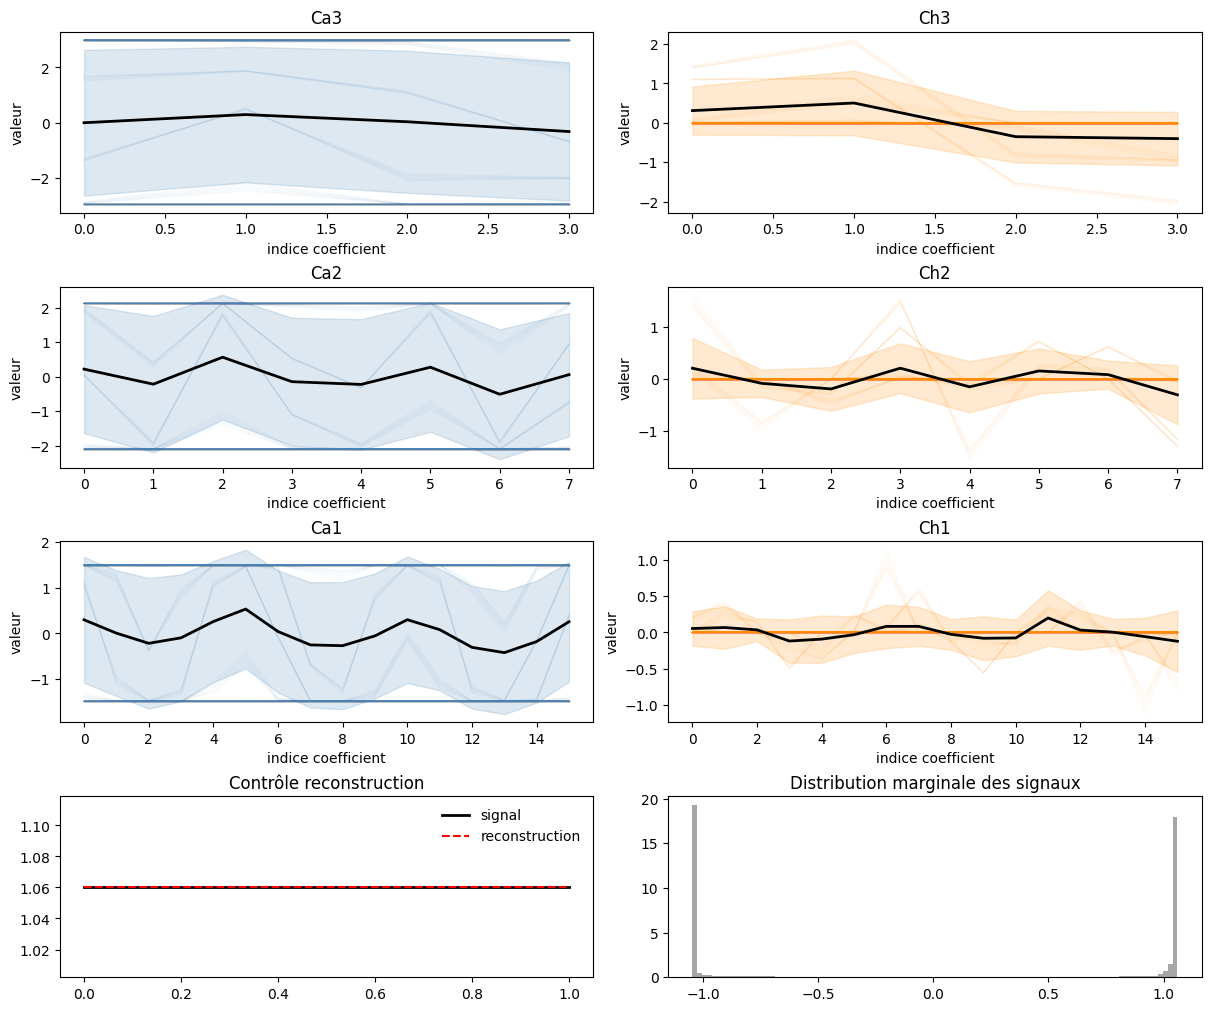

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), constrained_layout=True)
blocks = [
    (Ca3, "Ca3", "steelblue"),
    (Ch3, "Ch3", "darkorange"),
    (Ca2, "Ca2", "steelblue"),
    (Ch2, "Ch2", "darkorange"),
    (Ca1, "Ca1", "steelblue"),
    (Ch1, "Ch1", "darkorange"),
]

for axis, (block, name, color) in zip(axes.flat[:6], blocks):
    coef_signal_grid = torch.arange(block.shape[1])
    axis.plot(coef_signal_grid, block[:200].T, color=color, alpha=0.05, linewidth=0.8)
    axis.plot(coef_signal_grid, block.mean(dim=0), color="black", linewidth=2)
    axis.fill_between(
        coef_signal_grid.numpy(),
        (block.mean(dim=0) - block.std(dim=0)).numpy(),
        (block.mean(dim=0) + block.std(dim=0)).numpy(),
        color=color,
        alpha=0.18,
    )
    axis.set_title(name)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")

axes.flat[6].plot(signal_grid, dataset[0], color="black", linewidth=2, label="signal")
axes.flat[6].plot(signal_grid, reconstructed[0], color="red", linestyle="--", linewidth=1.5, label="reconstruction")
axes.flat[6].set_title("Contrôle reconstruction")
axes.flat[6].legend(frameon=False)
axes.flat[7].hist(dataset.flatten(), bins=100, density=True, color="gray", alpha=0.7)
axes.flat[7].set_title("Distribution marginale des signaux")
plt.show()


## Diffusion avant

Chaque variable de la cascade utilise le même processus DDPM coefficient par coefficient :

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon, \quad \epsilon\sim\mathcal{N}(0,I).$$

On distingue deux nombres de pas :

- `T_non_conditione` : utilisé uniquement pour le prior non conditionné `Ca3`.
- `T_conditionne` : utilisé pour `Ch3`, `Ch2`, `Ch1`; il est choisi automatiquement pour atteindre `SNR_THRESHOLD`.

L'alias `T = T_conditionne` est conservé pour limiter les changements dans les cellules suivantes.

In [8]:
# -----------------------------
# Configuration de diffusion
# -----------------------------
TIME_STEPS = 200          # longueur maximale du calendrier de bruit
T_non_conditione = 200    # uniquement pour le modèle non conditionné Ca3
SNR_THRESHOLD = 5         # seuil utilisé pour choisir T_conditionne
BETA_START = 1e-4
BETA_END = 5e-2


def get_schedule(steps=TIME_STEPS, device=None, dtype=torch.float32):
    """Retourne le préfixe de longueur `steps` du calendrier linéaire beta."""
    if steps < 1 or steps > TIME_STEPS:
        raise ValueError(f"steps doit appartenir à [1, {TIME_STEPS}], reçu {steps}.")

    betas = torch.linspace(
        BETA_START,
        BETA_END,
        TIME_STEPS,
        device=device,
        dtype=dtype,
    )[:steps]
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars


def snr_from_alpha_bar(alpha_bars):
    """SNR(t) = alpha_bar(t) / (1 - alpha_bar(t))."""
    denominator = (1.0 - alpha_bars).clamp_min(torch.finfo(alpha_bars.dtype).eps)
    return alpha_bars / denominator


def diffusion_steps_for_snr(snr_threshold, steps=TIME_STEPS, device=None, dtype=torch.float32):
    """Premier pas t tel que SNR(t) <= snr_threshold.

    Si le seuil n'est jamais atteint, on utilise `steps` et on signale `reached=False`.
    """
    _, _, alpha_bars = get_schedule(steps, device=device, dtype=dtype)
    snrs = snr_from_alpha_bar(alpha_bars)

    if snr_threshold is None:
        return steps, snrs[-1], True

    below_threshold = torch.nonzero(snrs <= snr_threshold, as_tuple=False)
    if len(below_threshold) == 0:
        return steps, snrs[-1], False

    selected_step = int(below_threshold[0].item()) + 1
    return selected_step, snrs[selected_step - 1], True


def q_sample(x0, t, eps=None, steps=TIME_STEPS):
    """Échantillonne x_t directement depuis x_0 pour un batch de temps t."""
    if eps is None:
        eps = torch.randn_like(x0)

    _, _, alpha_bars = get_schedule(
        steps,
        device=x0.device,
        dtype=x0.dtype,
    )
    alpha_bar_t = alpha_bars[t.long().flatten() - 1].view(-1, 1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return xt, eps


def do_diffusion_until_snr(data, snr_threshold=SNR_THRESHOLD, steps=TIME_STEPS):
    """Applique la diffusion avant jusqu'au seuil SNR et retourne l'historique."""
    samples = [data]
    xt = data
    stop_step, _, _ = diffusion_steps_for_snr(
        snr_threshold,
        steps=steps,
        device=data.device,
        dtype=data.dtype,
    )
    betas, alphas, _ = get_schedule(
        steps,
        device=data.device,
        dtype=data.dtype,
    )

    for i in range(stop_step):
        noise = torch.randn_like(xt)
        xt = torch.sqrt(alphas[i]) * xt + torch.sqrt(betas[i]) * noise
        samples.append(xt)

    return samples, stop_step


# Nombre de pas pour les modèles conditionnés.
_, T_conditionne = do_diffusion_until_snr(
    Ca3_train[:1],
    snr_threshold=SNR_THRESHOLD,
    steps=TIME_STEPS,
)
T = T_conditionne  # alias historique utilisé plus bas dans le notebook

_, _, alpha_bars_cpu = get_schedule(T_conditionne)
terminal_alpha_bar = alpha_bars_cpu[-1]
terminal_snr = snr_from_alpha_bar(terminal_alpha_bar)
snr_threshold_reached = bool(terminal_snr <= SNR_THRESHOLD)

print(
    f"T_conditionne = {T_conditionne}, T_non_conditione = {T_non_conditione}, "
    f"alpha_bar_T = {terminal_alpha_bar.item():.4g}, "
    f"SNR_T = {terminal_snr.item():.4g}, "
    f"SNR_THRESHOLD = {SNR_THRESHOLD:g}, reached = {snr_threshold_reached}"
)

T_conditionne = 39, T_non_conditione = 200, alpha_bar_T = 0.8267, SNR_T = 4.77, SNR_THRESHOLD = 5, reached = True


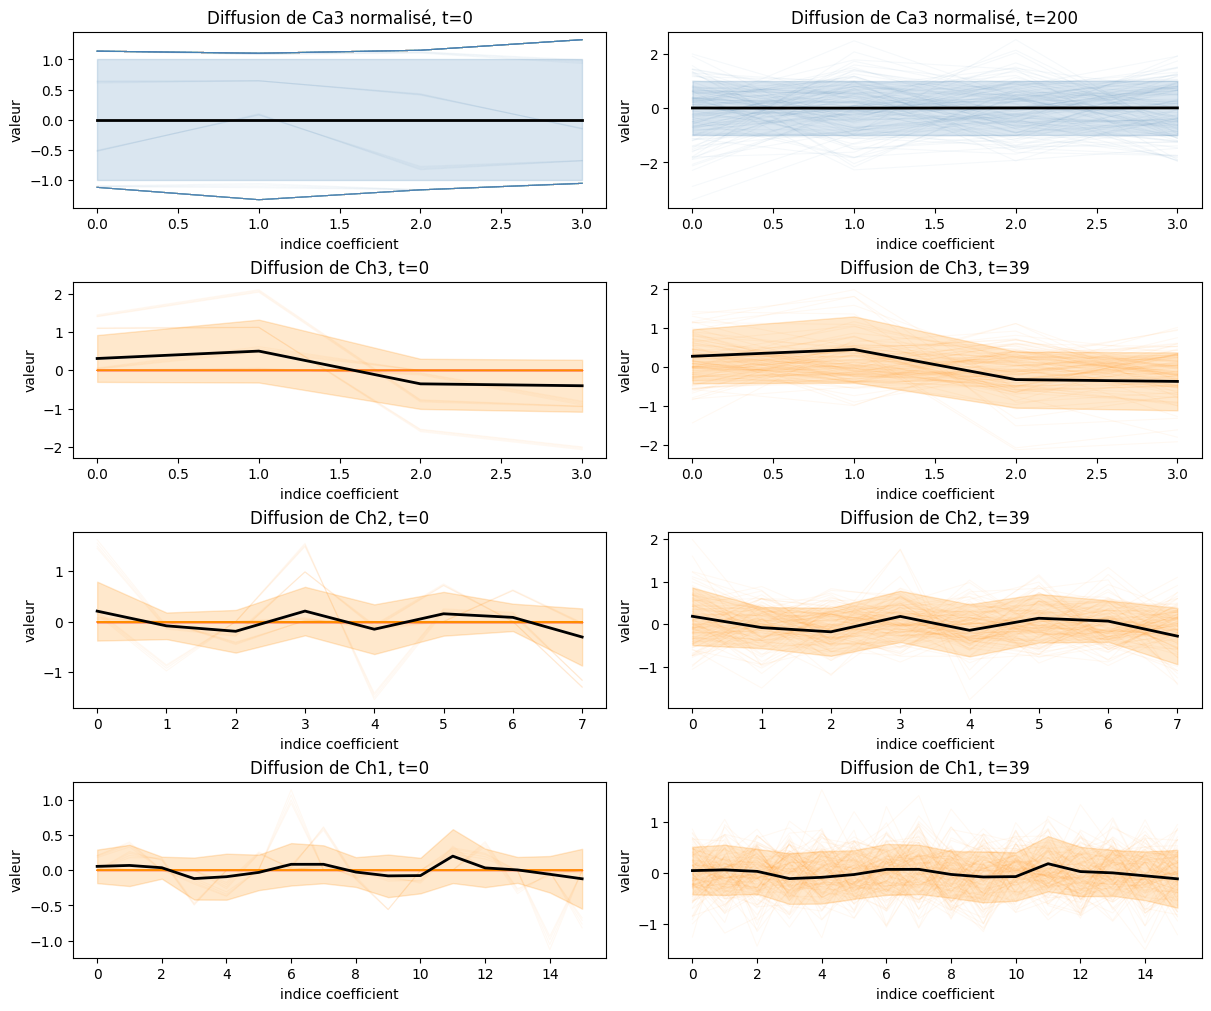

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), constrained_layout=True)

blocks_to_visualize = [
    (Ca3_train, "Ca3 normalisé", "steelblue", T_non_conditione),
    (Ch3, "Ch3", "darkorange", T_conditionne),
    (Ch2, "Ch2", "darkorange", T_conditionne),
    (Ch1, "Ch1", "darkorange", T_conditionne),
]

for row, (block, name, color, diffusion_steps) in enumerate(blocks_to_visualize):
    t_final = torch.full((block.shape[0], 1), diffusion_steps, dtype=torch.long)
    noisy_final, _ = q_sample(block, t_final, steps=diffusion_steps)
    coef_grid = torch.arange(block.shape[1])

    for col, (time_index, subset) in enumerate([(0, block), (diffusion_steps, noisy_final)]):
        mean_signal = subset.mean(dim=0)
        std_signal = subset.std(dim=0)
        axes[row, col].plot(coef_grid, subset[:120].T, color=color, alpha=0.05, linewidth=0.8)
        axes[row, col].plot(coef_grid, mean_signal, color="black", linewidth=2)
        axes[row, col].fill_between(
            coef_grid.numpy(),
            (mean_signal - std_signal).numpy(),
            (mean_signal + std_signal).numpy(),
            color=color,
            alpha=0.2,
        )
        axes[row, col].set_title(f"Diffusion de {name}, t={time_index}")
        axes[row, col].set_xlabel("indice coefficient")
        axes[row, col].set_ylabel("valeur")

plt.show()

# Entraînement de la cascade

On entraîne quatre estimateurs de bruit indépendants :

- `Ca3_non_conditionné` : prior non conditionné de `Ca3`.
- `Ch3_Ca3` : détail `Ch3` conditionné par `Ca3`.
- `Ch2_Ca2` : détail `Ch2` conditionné par `Ca2`.
- `Ch1_Ca1` : détail `Ch1` conditionné par `Ca1`.

Pendant l'entraînement, les conditions `Ca3`, `Ca2`, `Ca1` sont les conditions exactes calculées depuis le dataset.
Pendant la génération, elles sont remplacées récursivement par les approximations générées. Cette différence est une source possible d'accumulation d'erreur.

In [10]:
# Architecture du prior non conditionné Ca3.
# Options disponibles : "mlp", "residual_mlp", "conv1d".
CA3_ARCHITECTURE = "conv1d"

# Fréquences utilisées pour encoder le temps de diffusion.
TIME_EMBED_FREQS = (1.0, 2.0, 4.0, 8.0, 16.0)
MODEL_VERSION_BASE = f"max{TIME_STEPS}_linear_{BETA_START:g}_{BETA_END:g}_timeff{len(TIME_EMBED_FREQS)}"


# -----------------------------
# Encodage du temps
# -----------------------------
def time_feature_dim():
    return 1 + 2 * len(TIME_EMBED_FREQS)


def diffusion_time_features(t, T):
    tau = t.to(dtype=torch.float32) / T
    tau = tau.to(device=t.device)
    features = [tau]
    for freq in TIME_EMBED_FREQS:
        arg = torch.pi * freq * tau
        features.append(torch.sin(arg))
        features.append(torch.cos(arg))
    return torch.cat(features, dim=1)


# -----------------------------
# Architectures possibles pour epsilon_theta
# -----------------------------
class ResidualBlock(torch.nn.Module):
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.LayerNorm(dim),
            torch.nn.Linear(dim, dim),
            torch.nn.SiLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.net(x)


class ResidualEpsMLP(torch.nn.Module):
    def __init__(self, input_dim, target_dim, hidden_dim=256, blocks=4, dropout=0.05):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.SiLU(),
            *[ResidualBlock(hidden_dim, dropout=dropout) for _ in range(blocks)],
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.Linear(hidden_dim, target_dim),
        )

    def forward(self, features):
        return self.net(features)


class ConvEpsModel(torch.nn.Module):
    """Petit score network 1D. Utile à tester, mais l'inductive bias est faible pour Ca3 de taille 4."""
    def __init__(self, target_dim, context_dim, hidden_dim=96, blocks=3):
        super().__init__()
        self.target_dim = target_dim
        self.context_dim = context_dim

        self.context = torch.nn.Sequential(
            torch.nn.Linear(context_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
        )
        self.in_proj = torch.nn.Conv1d(2, hidden_dim, kernel_size=1)
        self.convs = torch.nn.ModuleList([
            torch.nn.Sequential(
                torch.nn.GroupNorm(8, hidden_dim),
                torch.nn.SiLU(),
                torch.nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
                torch.nn.GroupNorm(8, hidden_dim),
                torch.nn.SiLU(),
                torch.nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            )
            for _ in range(blocks)
        ])
        self.out = torch.nn.Sequential(
            torch.nn.GroupNorm(8, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Conv1d(hidden_dim, 1, kernel_size=1),
        )

    def forward(self, features):
        xt = features[:, :self.target_dim]
        context = features[:, self.target_dim:]
        position = torch.linspace(
            -1.0,
            1.0,
            self.target_dim,
            device=features.device,
            dtype=features.dtype,
        ).expand_as(xt)

        x = torch.stack([xt, position], dim=1)
        h = self.in_proj(x)
        context_bias = self.context(context).unsqueeze(-1)
        h = h + context_bias

        for conv in self.convs:
            h = h + conv(h)

        return self.out(h).squeeze(1)


def make_eps_model(target_dim, condition_dim=0, hidden_dim=128, architecture="mlp"):
    input_dim = target_dim + time_feature_dim() + condition_dim

    if architecture == "mlp":
        return torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, target_dim),
        )

    if architecture == "residual_mlp":
        return ResidualEpsMLP(
            input_dim=input_dim,
            target_dim=target_dim,
            hidden_dim=hidden_dim,
            blocks=4,
            dropout=0.05,
        )

    if architecture == "conv1d":
        return ConvEpsModel(
            target_dim=target_dim,
            context_dim=time_feature_dim() + condition_dim,
            hidden_dim=max(64, min(hidden_dim, 128)),
            blocks=3,
        )

    raise ValueError(f"Architecture inconnue: {architecture}")


# -----------------------------
# Loss DDPM
# -----------------------------
def compute_features(xt, t, T, condition=None):
    features = [xt, diffusion_time_features(t, T).to(device=xt.device, dtype=xt.dtype)]
    if condition is not None:
        features.append(condition.to(device=xt.device, dtype=xt.dtype))
    return torch.cat(features, dim=1)


def compute_loss(x0, condition, model, T):
    batch_size = x0.shape[0]
    t = torch.randint(1, T + 1, (batch_size, 1), device=x0.device)
    eps = torch.randn_like(x0)
    xt, eps = q_sample(x0, t, eps=eps, steps=T)

    features = compute_features(xt, t, T, condition)
    eps_pred = model(features)
    return F.mse_loss(eps_pred, eps)


# -----------------------------
# Entraînement et checkpoints
# -----------------------------
def train_diffusion_model(
    name,
    target,
    T,
    condition=None,
    epochs=500,
    batch_size=256,
    lr=1e-3,
    architecture="mlp",
    hidden_dim=None,
):
    model_version = f"eps_T{T}_{MODEL_VERSION_BASE}"
    model_path = MODEL_DIR / f"{name}_{architecture}_{model_version}.pt"

    target_dim = target.shape[1]
    condition_dim = 0 if condition is None else condition.shape[1]
    if hidden_dim is None:
        hidden_dim = 256 if condition is None else 128

    model = make_eps_model(
        target_dim,
        condition_dim=condition_dim,
        hidden_dim=hidden_dim,
        architecture=architecture,
    ).to(DEVICE)

    if model_path.exists() and not FORCE_RETRAIN:
        print(f"Chargement : {model_path}")
        checkpoint = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        loss_history = checkpoint.get("loss_history", [])
        return model, loss_history

    print(f"Entraînement : {name} ({architecture})")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, epochs),
        eta_min=lr * 0.05,
    )

    tensors = (target,) if condition is None else (target, condition)
    loader = DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=True, drop_last=False)
    loss_history = []

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"{name} epoch {epoch + 1}/{epochs}", leave=False)
        for batch in pbar:
            x_batch = batch[0].to(DEVICE)
            c_batch = None if condition is None else batch[1].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            loss = compute_loss(x_batch, c_batch, model, T)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            loss_history.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
        scheduler.step()

    torch.save({
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
        "target_dim": target_dim,
        "condition_dim": condition_dim,
        "hidden_dim": hidden_dim,
        "architecture": architecture,
        "T": T,
        "beta_start": BETA_START,
        "beta_end": BETA_END,
        "time_embed_freqs": TIME_EMBED_FREQS,
        "prediction": "epsilon",
    }, model_path)

    return model, loss_history

In [11]:
EPOCHS_NB = 25
models = {}
loss_histories = {}

# 1) Prior basse fréquence non conditionné.
#    Il utilise T_non_conditione, indépendamment du seuil SNR des modèles conditionnés.
models["Ca3"], loss_histories["Ca3"] = train_diffusion_model(
    name="Ca3_non_conditionné",
    target=Ca3_train,
    T=T_non_conditione,
    condition=None,
    epochs=EPOCHS_NB,
    batch_size=512,
    lr=5e-4,
    architecture=CA3_ARCHITECTURE,
    hidden_dim=256,
)

# 2) Modèles de détail conditionnés.
#    Ils utilisent tous T_conditionne, choisi par SNR_THRESHOLD.
models["Ch3"], loss_histories["Ch3"] = train_diffusion_model(
    name="Ch3_Ca3",
    target=Ch3,
    T=T_conditionne,
    condition=Ca3,
    epochs=EPOCHS_NB,
    architecture="mlp",
)
models["Ch2"], loss_histories["Ch2"] = train_diffusion_model(
    name="Ch2_Ca2",
    target=Ch2,
    T=T_conditionne,
    condition=Ca2,
    epochs=EPOCHS_NB,
    architecture="mlp",
)
models["Ch1"], loss_histories["Ch1"] = train_diffusion_model(
    name="Ch1_Ca1",
    target=Ch1,
    T=T_conditionne,
    condition=Ca1,
    epochs=EPOCHS_NB,
    architecture="mlp",
)

Chargement : /home/chapuissamuel/Documents/code/RT-Diffusion/exemples/saved_models/Ca3_non_conditionné_conv1d_eps_T200_max200_linear_0.0001_0.05_timeff5.pt
Chargement : /home/chapuissamuel/Documents/code/RT-Diffusion/exemples/saved_models/Ch3_Ca3_mlp_eps_T39_max200_linear_0.0001_0.05_timeff5.pt
Chargement : /home/chapuissamuel/Documents/code/RT-Diffusion/exemples/saved_models/Ch2_Ca2_mlp_eps_T39_max200_linear_0.0001_0.05_timeff5.pt
Chargement : /home/chapuissamuel/Documents/code/RT-Diffusion/exemples/saved_models/Ch1_Ca1_mlp_eps_T39_max200_linear_0.0001_0.05_timeff5.pt


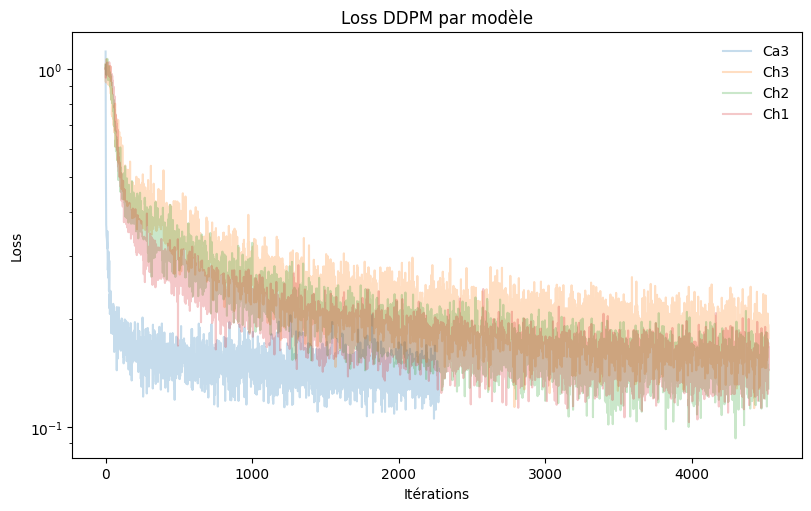

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for name, history in loss_histories.items():
    ax.plot(history, label=name, alpha=0.25)
ax.set_yscale("log")
ax.set_ylabel("Loss")
ax.set_xlabel("Itérations")
ax.set_title("Loss DDPM par modèle")
ax.legend(frameon=False)
plt.show()


# Génération hiérarchique et test

La génération suit l'ordre de la cascade :

1. générer `Ca3` avec le modèle non conditionné ;
2. générer `Ch3 | Ca3` ;
3. reconstruire `Ca2 = W^{-1}(Ca3, Ch3)` ;
4. générer `Ch2 | Ca2` ;
5. reconstruire `Ca1 = W^{-1}(Ca2, Ch2)` ;
6. générer `Ch1 | Ca1` ;
7. reconstruire le signal complet.

In [13]:
def sample_reverse(model, target_dim, steps, condition=None, count=None, return_history=False):
    """Échantillonnage DDPM inverse pour un seul réseau epsilon_theta."""
    device = next(model.parameters()).device
    dtype = next(model.parameters()).dtype
    was_training = model.training
    model.eval()

    if condition is not None:
        condition = condition.to(device=device, dtype=dtype)
        count = condition.shape[0]
    elif count is None:
        raise ValueError("count doit être fourni pour un sampling non conditionné.")

    betas, alphas, alpha_bars = get_schedule(
        steps,
        device=device,
        dtype=dtype,
    )

    sample_history = []
    with torch.inference_mode():
        xt = torch.randn(count, target_dim, device=device, dtype=dtype)
        if return_history:
            sample_history.append(xt.detach().cpu())

        for step in range(steps, 0, -1):
            t = torch.full((count, 1), step, device=device, dtype=torch.long)
            features = compute_features(xt, t, steps, condition)
            eps_pred = model(features)

            beta_t = betas[step - 1]
            alpha_t = alphas[step - 1]
            alpha_bar_t = alpha_bars[step - 1]

            mean = (xt - beta_t / torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_t)

            if step > 1:
                alpha_bar_prev = alpha_bars[step - 2]
                posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)
                xt = mean + torch.sqrt(posterior_var) * torch.randn_like(xt)
            else:
                xt = mean

            if return_history:
                sample_history.append(xt.detach().cpu())

    if was_training:
        model.train()

    if return_history:
        return torch.stack(sample_history)
    return xt.detach().cpu()


def sample_wavelet_cascade(
    models,
    count,
    conditioned_steps=T_conditionne,
    ca3_steps=T_non_conditione,
):
    """Génère un batch complet avec la cascade ondelette.

    `ca3_steps` ne concerne que le prior Ca3.
    `conditioned_steps` concerne Ch3, Ch2 et Ch1.
    """
    generated_ca3 = sample_reverse(
        models["Ca3"],
        target_dim=Ca3.shape[1],
        steps=ca3_steps,
        count=count,
    )
    generated_ca3 = generated_ca3 * Ca3_std + Ca3_mean

    generated_ch3 = sample_reverse(
        models["Ch3"],
        target_dim=Ch3.shape[1],
        steps=conditioned_steps,
        condition=generated_ca3,
    )
    generated_ca2 = idwt_pair(generated_ca3, generated_ch3, wavelet=WAVELET)

    generated_ch2 = sample_reverse(
        models["Ch2"],
        target_dim=Ch2.shape[1],
        steps=conditioned_steps,
        condition=generated_ca2,
    )
    generated_ca1 = idwt_pair(generated_ca2, generated_ch2, wavelet=WAVELET)

    generated_ch1 = sample_reverse(
        models["Ch1"],
        target_dim=Ch1.shape[1],
        steps=conditioned_steps,
        condition=generated_ca1,
    )
    generated_signals = idwt_pair(generated_ca1, generated_ch1, wavelet=WAVELET)[:, :SIGNAL_SIZE]

    return {
        "Ca3": generated_ca3.contiguous(),
        "Ch3": generated_ch3.contiguous(),
        "Ca2": generated_ca2.contiguous(),
        "Ch2": generated_ch2.contiguous(),
        "Ca1": generated_ca1.contiguous(),
        "Ch1": generated_ch1.contiguous(),
        "signals": generated_signals.contiguous(),
    }


GENERATED_BLOCKS = ("Ca3", "Ch3", "Ca2", "Ch2", "Ca1", "Ch1", "signals")


def generated_shapes(count):
    return {
        "Ca3": (count, Ca3.shape[1]),
        "Ch3": (count, Ch3.shape[1]),
        "Ca2": (count, Ca2.shape[1]),
        "Ch2": (count, Ch2.shape[1]),
        "Ca1": (count, Ca1.shape[1]),
        "Ch1": (count, Ch1.shape[1]),
        "signals": (count, SIGNAL_SIZE),
    }


def load_generated_cascade(output_dir, mmap_mode="r+"):
    output_dir = Path(output_dir)
    generated = {}
    for name in GENERATED_BLOCKS:
        array = np.load(output_dir / f"{name}.npy", mmap_mode=mmap_mode)
        generated[name] = torch.from_numpy(array)
    return generated


def sample_wavelet_cascade_to_disk(
    models,
    count,
    output_dir,
    batch_size=512,
    conditioned_steps=T_conditionne,
    ca3_steps=T_non_conditione,
    overwrite=True,
):
    """Génère `count` signaux par batch et les sauvegarde en fichiers .npy.

    La sauvegarde évite de garder toute la génération en mémoire GPU/CPU pendant le sampling.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mode = "w+" if overwrite else "r+"
    arrays = {
        name: np.lib.format.open_memmap(
            output_dir / f"{name}.npy",
            mode=mode,
            dtype=np.float32,
            shape=shape,
        )
        for name, shape in generated_shapes(count).items()
    }

    for start in tqdm(range(0, count, batch_size), desc="Génération sur disque"):
        end = min(start + batch_size, count)
        chunk = sample_wavelet_cascade(
            models,
            count=end - start,
            conditioned_steps=conditioned_steps,
            ca3_steps=ca3_steps,
        )

        for name, values in chunk.items():
            arrays[name][start:end] = values.detach().cpu().to(torch.float32).numpy()
            arrays[name].flush()

        del chunk
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del arrays
    return load_generated_cascade(output_dir)


def tensor_batch_iterator(x, batch_size=8192):
    for start in range(0, len(x), batch_size):
        yield x[start:start + batch_size]


def tensor_mean(x, batch_size=8192, dtype=torch.float64):
    total = None
    n_total = 0
    for batch in tensor_batch_iterator(x, batch_size=batch_size):
        batch = torch.as_tensor(batch).detach().cpu().to(dtype=dtype)
        total = batch.sum(dim=0) if total is None else total + batch.sum(dim=0)
        n_total += batch.shape[0]
    return (total / n_total).to(dtype=torch.float32)


def tensor_mean_and_cov(x, batch_size=8192):
    sum_x = None
    sum_xx = None
    n_total = 0

    for batch in tensor_batch_iterator(x, batch_size=batch_size):
        batch = torch.as_tensor(batch).detach().cpu().to(dtype=torch.float64)
        sum_x = batch.sum(dim=0) if sum_x is None else sum_x + batch.sum(dim=0)
        sum_xx = batch.T @ batch if sum_xx is None else sum_xx + batch.T @ batch
        n_total += batch.shape[0]

    mean = sum_x / n_total
    if n_total > 1:
        cov = (sum_xx - n_total * torch.outer(mean, mean)) / (n_total - 1)
    else:
        cov = torch.zeros((mean.numel(), mean.numel()), dtype=torch.float64)
    return mean.numpy(), cov.numpy()

In [14]:
num_generated = 5_000
GENERATION_BATCH_SIZE = 512
GENERATED_OUTPUT_DIR = (
    CURRENT_DIR
    / "generated_data"
    / f"wavelet_cascade_Tcond{T_conditionne}_Tnoncond{T_non_conditione}_snr{SNR_THRESHOLD:g}_N{num_generated}"
)

generated = sample_wavelet_cascade_to_disk(
    models=models,
    count=num_generated,
    output_dir=GENERATED_OUTPUT_DIR,
    batch_size=GENERATION_BATCH_SIZE,
    conditioned_steps=T_conditionne,
    ca3_steps=T_non_conditione,
    overwrite=True,
)
generated_signals = generated["signals"]

num_reference = min(num_generated, len(dataset))
original_signals = dataset[:num_reference]

# Baseline : reconstruction exacte à partir des vrais coefficients ondelettes.
exact_reconstructed_signals = waverec_tensor(
    [Ca3[:num_reference], Ch3[:num_reference], Ch2[:num_reference], Ch1[:num_reference]],
    wavelet=WAVELET,
    length=SIGNAL_SIZE,
)

exact_rmse = torch.mean((exact_reconstructed_signals - original_signals.cpu()) ** 2).sqrt()
generated_distribution_rmse = torch.mean(
    (tensor_mean(generated_signals) - tensor_mean(original_signals)) ** 2
).sqrt()

print("Reconstruction inverse exacte RMSE   =", exact_rmse.item())
print("RMSE moyenne générée/originale       =", generated_distribution_rmse.item())
print("generated_signals.shape              =", generated_signals.shape)
print("Données générées sauvegardées dans   =", GENERATED_OUTPUT_DIR)

Génération sur disque:   0%|          | 0/10 [00:00<?, ?it/s]

Génération sur disque: 100%|██████████| 10/10 [00:44<00:00,  4.46s/it]

Reconstruction inverse exacte RMSE   = 1.1433493085633017e-07
RMSE moyenne générée/originale       = 0.06392394006252289
generated_signals.shape              = torch.Size([5000, 32])
Données générées sauvegardées dans   = /home/chapuissamuel/Documents/code/RT-Diffusion/exemples/generated_data/wavelet_cascade_Tcond39_Tnoncond200_snr5_N5000


# Pseudo-FID dans l'espace des coefficients

Ce score reprend la formule du FID gaussien, mais il est calculé directement dans l'espace des signaux ou des coefficients ondelettes.
Ce n'est donc pas le FID image standard, qui est normalement calculé dans un espace latent d'un réseau pré-entraîné.

Ici, l'espace est de faible dimension, donc ce score reste utile comme diagnostic de moments d'ordre 1 et 2 :

$$
\left\|\mu_r - \mu_g\right\|_2^2
+
\mathrm{Tr}
\left(
\Sigma_r + \Sigma_g - 2\left(\Sigma_r\Sigma_g\right)^{1/2}
\right).
$$

In [19]:
from scipy.linalg import sqrtm
import numpy as np

GENERATED = 10000
BATCH_SIZE = 512

def compute_pseudo_fid_terms(real, fake, batch_size=8192):
    mu_real, sigma_real = tensor_mean_and_cov(real, batch_size=batch_size)
    mu_fake, sigma_fake = tensor_mean_and_cov(fake, batch_size=batch_size)

    diff = mu_real - mu_fake
    covmean = sqrtm(sigma_real @ sigma_fake)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    mean_term = diff @ diff
    cov_term = np.trace(sigma_real + sigma_fake - 2 * covmean)
    return float(mean_term), float(cov_term), float(mean_term + cov_term)


def compute_pseudo_fid(real, fake, batch_size=8192):
    return compute_pseudo_fid_terms(real, fake, batch_size=batch_size)[-1]


def sample_random_subset(x, count):
    """Échantillonne un sous-ensemble aléatoire de `count` éléments depuis le tenseur `x`."""
    if count >= len(x):
        return x
    indices = torch.randperm(len(x))[:count]
    return x[indices]


Ca3s = sample_random_subset(Ca3, GENERATED)
Ch3s = sample_random_subset(Ch3, GENERATED)
Ch2s = sample_random_subset(Ch2, GENERATED)
Ch1s = sample_random_subset(Ch1, GENERATED)

# Alias court conservé si d'anciennes cellules appellent encore compute_fid.
compute_fid = compute_pseudo_fid


print("Pseudo-FID original Ca3    :", compute_pseudo_fid(Ca3, Ca3s))
print("Pseudo-FID original Ch3    :", compute_pseudo_fid(Ch3, Ch3s))
print("Pseudo-FID original Ch2    :", compute_pseudo_fid(Ch2, Ch2s))
print("Pseudo-FID original Ch1    :", compute_pseudo_fid(Ch1, Ch1s))
print("Pseudo-FID original Signal :", compute_pseudo_fid(dataset[:num_reference], dataset[:num_reference]))

print("=================")

for name, real_block in [
    ("Ca3", Ca3),
    ("Ch3", Ch3),
    ("Ch2", Ch2),
    ("Ch1", Ch1),
]:
    mean_term, cov_term, fid = compute_pseudo_fid_terms(real_block, generated[name])
    print(f"Pseudo-FID {name:<4}: {fid:.6g}  mean={mean_term:.6g}  cov={cov_term:.6g}")

mean_term, cov_term, fid = compute_pseudo_fid_terms(
    dataset[:num_reference],
    generated["signals"],
)
print(f"Pseudo-FID Signal: {fid:.6g}  mean={mean_term:.6g}  cov={cov_term:.6g}")


def train_and_score_ca3_architectures(
    architectures=("residual_mlp", "conv1d"),
    epochs=EPOCHS_NB,
    count=GENERATED,
):
    """Comparaison locale des priors Ca3. A lancer explicitement si tu veux benchmarker conv1d."""
    scores = []
    for architecture in architectures:
        model, history = train_diffusion_model(
            f"Ca3_non_conditionné_compare_{architecture}",
            Ca3_train,
            T=T_non_conditione,
            condition=None,
            epochs=epochs,
            batch_size=BATCH_SIZE,
            lr=5e-4,
            architecture=architecture,
            hidden_dim=256,
        )
        sampled = sample_reverse(
            model,
            target_dim=Ca3.shape[1],
            steps=T_non_conditione,
            count=count,
        )
        sampled = sampled * (Ca3_std + 1e-8) + Ca3_mean
        mean_term, cov_term, fid = compute_pseudo_fid_terms(Ca3, sampled)
        scores.append({
            "architecture": architecture,
            "fid": fid,
            "mean_term": mean_term,
            "cov_term": cov_term,
            "last_loss": history[-1] if len(history) else np.nan,
        })
    return scores

# Exemple volontairement non exécuté automatiquement :
# train_and_score_ca3_architectures(architectures=("residual_mlp", "conv1d"), epochs=EPOCHS_NB)

Pseudo-FID original Ca3    : 0.002195947526909392
Pseudo-FID original Ch3    : 0.00010754349230547645
Pseudo-FID original Ch2    : 0.0003074022083905122
Pseudo-FID original Ch1    : 0.0008921550831907501
Pseudo-FID original Signal : -6.055156376305604e-13
Pseudo-FID Ca3 : 0.0193195  mean=0.0158544  cov=0.00346501
Pseudo-FID Ch3 : 0.344488  mean=0.109248  cov=0.23524
Pseudo-FID Ch2 : 0.256955  mean=0.0538335  cov=0.203122
Pseudo-FID Ch1 : 0.240513  mean=0.0221174  cov=0.218396
Pseudo-FID Signal: 0.76382  mean=0.130761  cov=0.633059


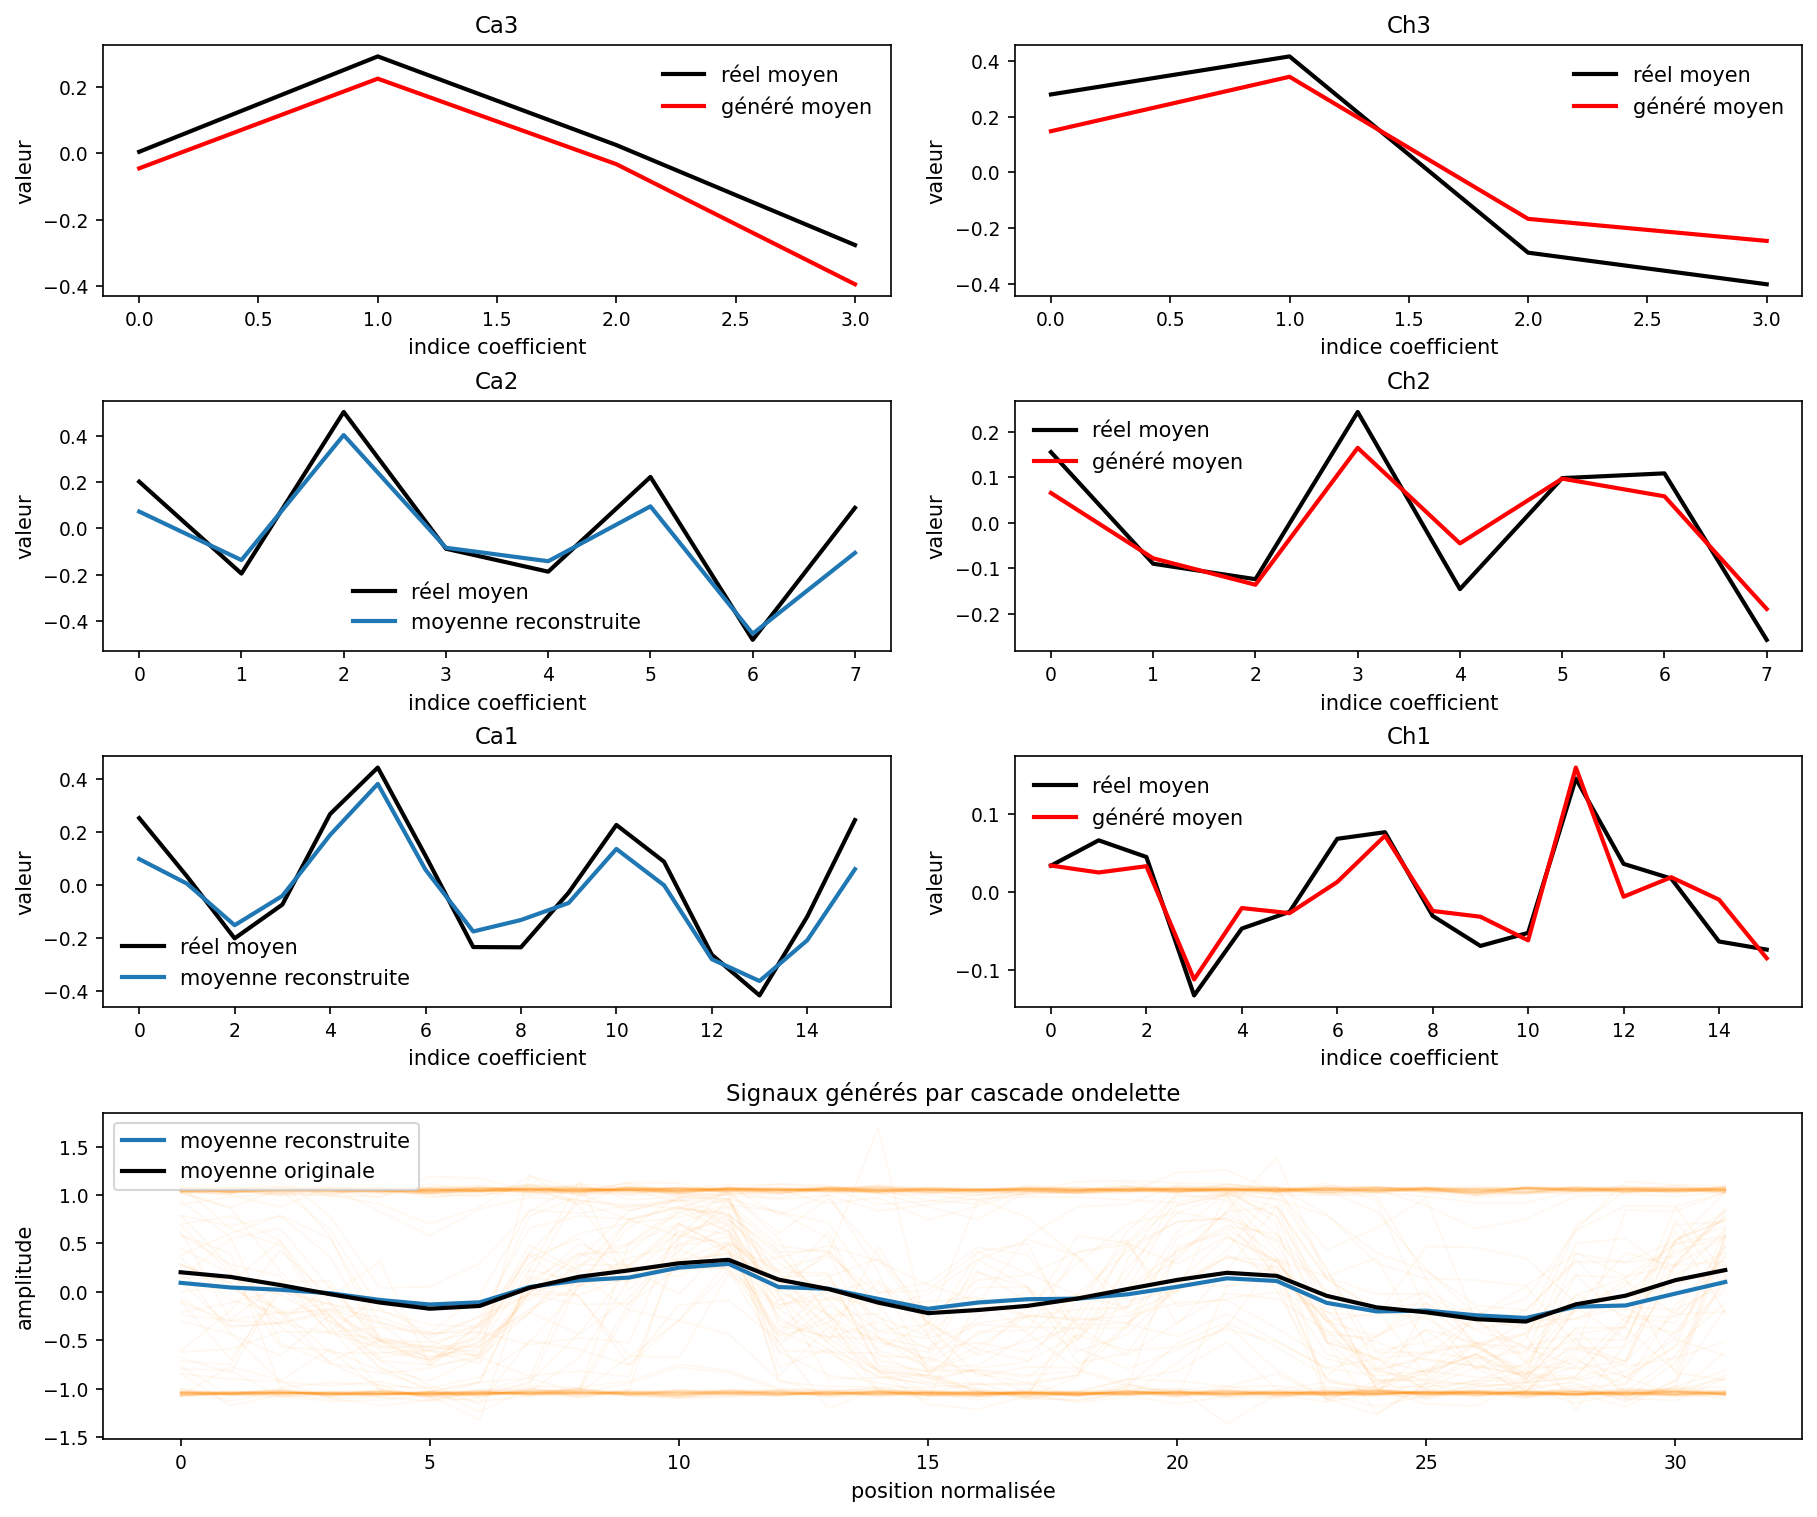

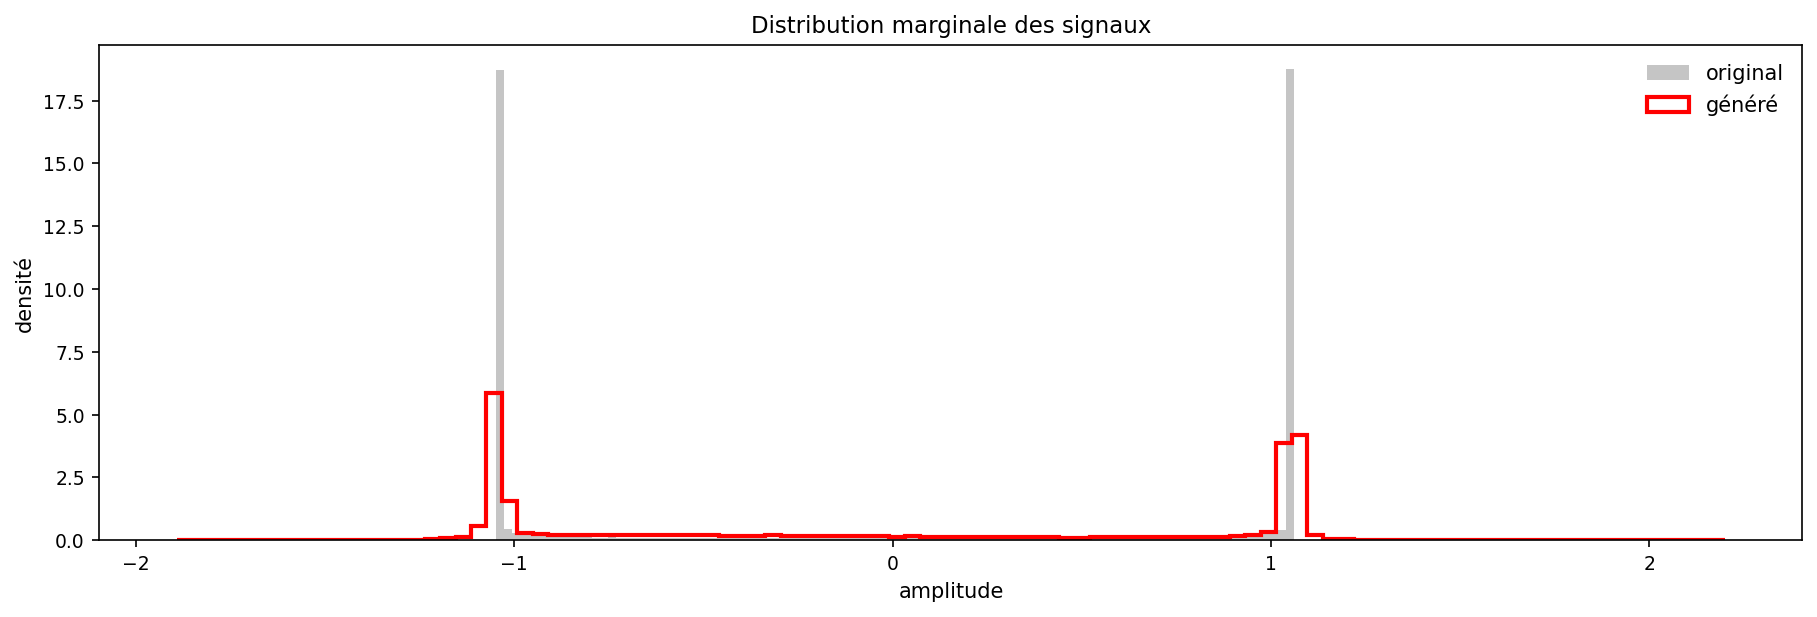

In [16]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

plot_count = min(120, len(generated_signals))
hist_count = min(GENERATED, len(generated_signals))

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(4, 2, height_ratios=[1.0, 1.0, 1.0, 1.3])

ax_all = fig.add_subplot(gs[3, :])
ax_blocks = [fig.add_subplot(gs[i, j]) for i in range(0, 3) for j in range(2)]

plot_grid = torch.arange(generated_signals.shape[1])
ax_all.plot(plot_grid, generated_signals[:plot_count].T, color="darkorange", alpha=0.06, linewidth=0.8)
ax_all.plot(plot_grid, tensor_mean(generated_signals), color="tab:blue", linewidth=2, label="moyenne reconstruite")
ax_all.plot(plot_grid, tensor_mean(original_signals), color="black", linewidth=2, label="moyenne originale")
ax_all.set_title("Signaux générés par cascade ondelette")
ax_all.set_xlabel("position normalisée")
ax_all.set_ylabel("amplitude")
ax_all.legend(loc="upper left")

for axis, name, real_block in zip(
    ax_blocks,
    ["Ca3", "Ch3", "Ca2", "Ch2", "Ca1", "Ch1"],
    [Ca3, Ch3, Ca2, Ch2, Ca1, Ch1],
):
    fake_block = generated[name]
    coef_grid = torch.arange(real_block.shape[1])
    axis.plot(coef_grid, tensor_mean(real_block[:num_reference]), color="black", linewidth=2, label="réel moyen")
    if name in ["Ca2", "Ca1"]:
        color = "tab:blue"
        label = "moyenne reconstruite"
    else:
        color = "red"
        label = "généré moyen"

    axis.plot(coef_grid, tensor_mean(fake_block), color=color, linewidth=2, label=label)
    axis.set_title(name)
    axis.set_xlabel("indice coefficient")
    axis.set_ylabel("valeur")
    axis.legend(frameon=False)

plt.savefig("500-epochs-generated_signals_and_coefficients.png", dpi=150)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
ax.hist(original_signals[:hist_count].flatten(), bins=100, density=True, color="gray", alpha=0.45, label="original")
ax.hist(generated_signals[:hist_count].flatten(), bins=100, density=True, histtype="step", linewidth=2, color="red", label="généré")
ax.set_title("Distribution marginale des signaux")
ax.set_xlabel("amplitude")
ax.set_ylabel("densité")
ax.legend(frameon=False)

plt.savefig("500-epochs-generated_signals_distribution.png", dpi=150)
plt.show()

# Attention : comparaison au plus proche voisin

Les signaux générés ne correspondent pas à un signal réel précis du dataset : le prior `Ca3` est non conditionné.
Les graphes suivants comparent donc chaque signal généré au plus proche voisin du dataset, au sens de la distance quadratique moyenne :

$$x^*_{reel} = \arg\min_i \|x_{generated} - x_i\|_2.$$

Cette visualisation est utile pour détecter des formes aberrantes, mais elle ne mesure pas une reconstruction supervisée.

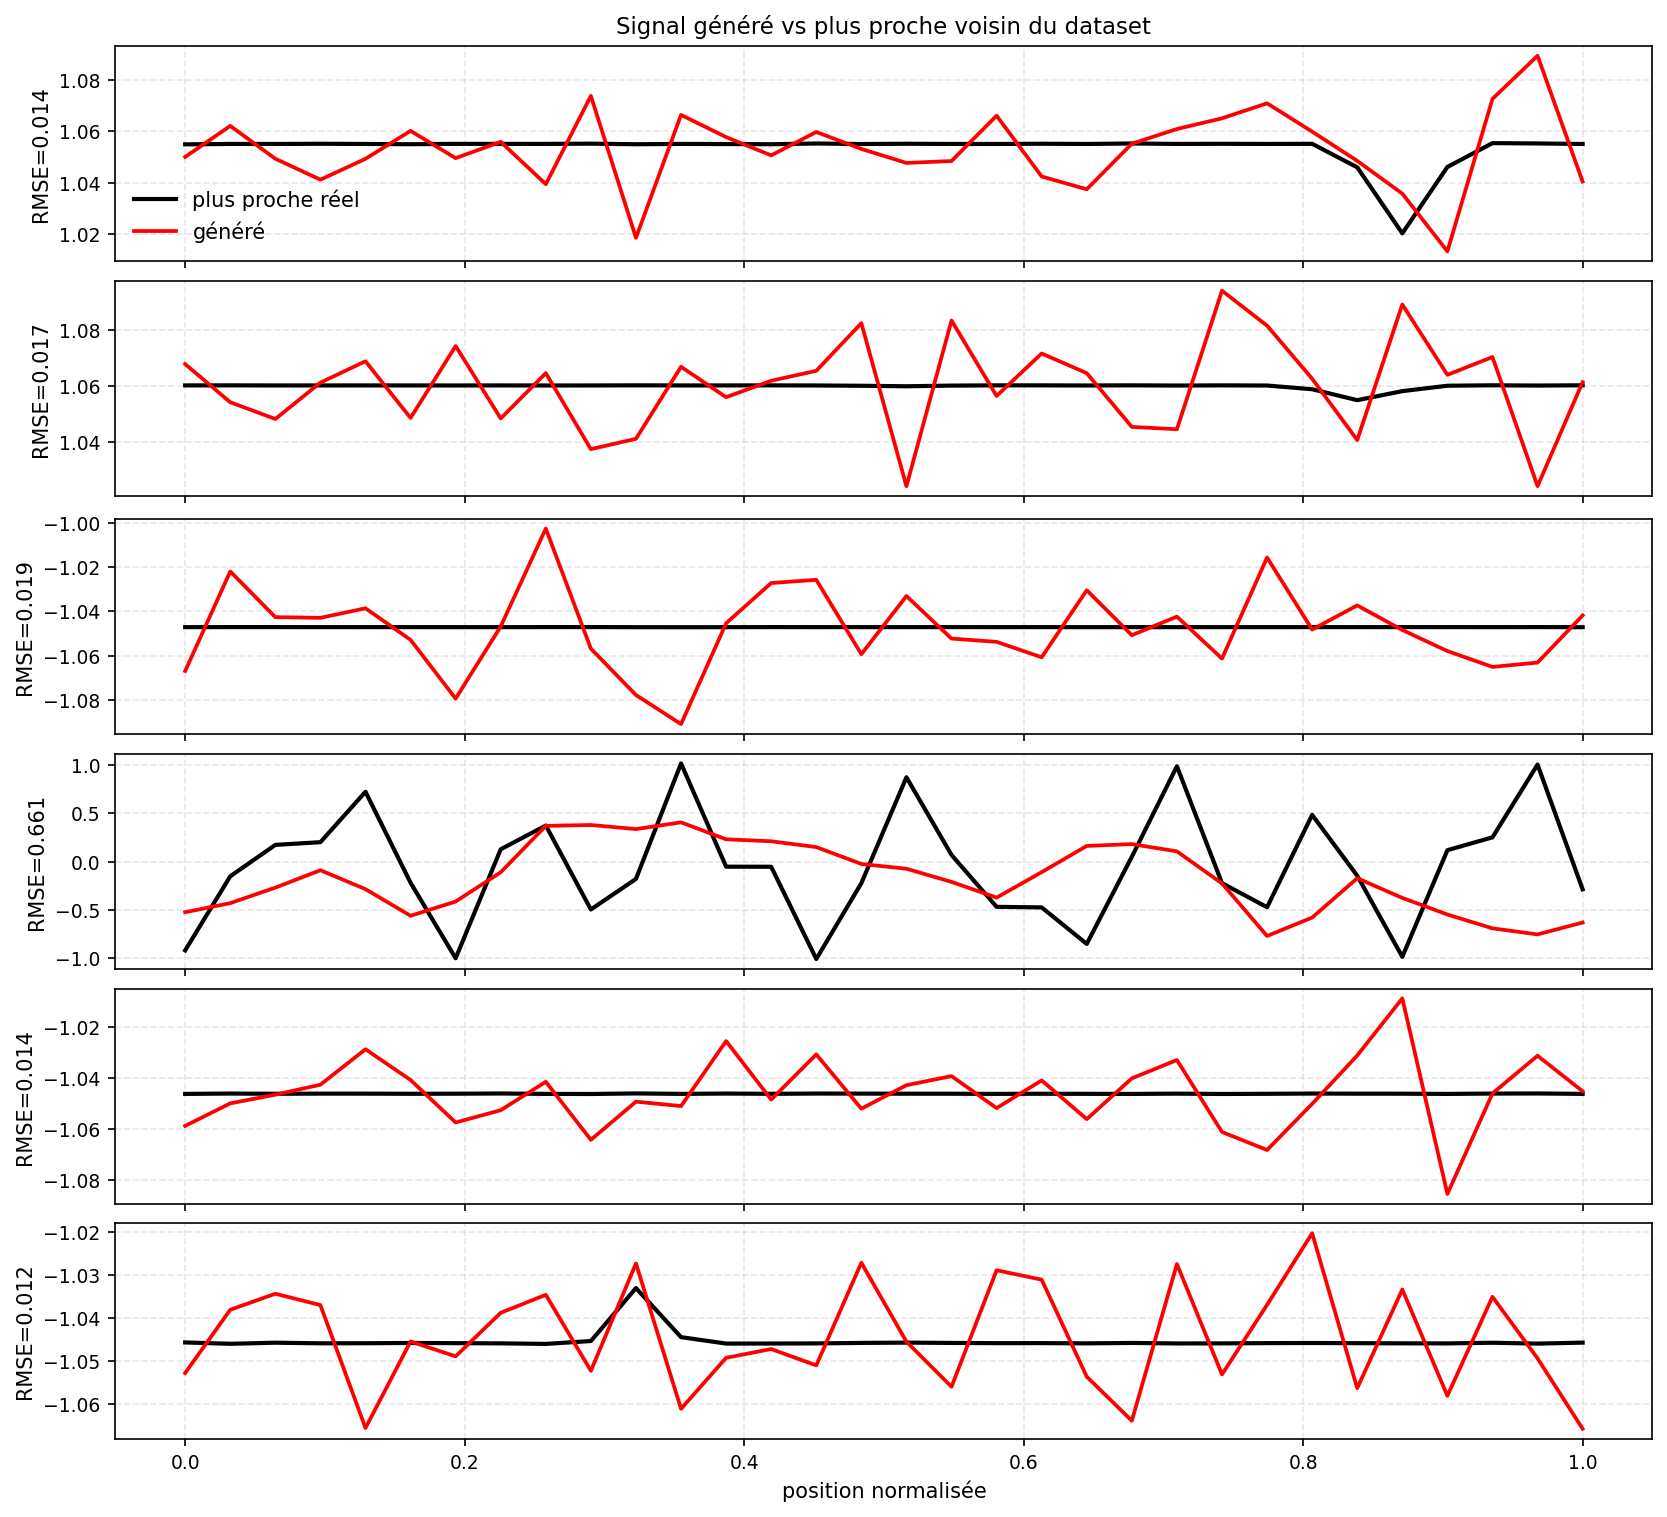

In [17]:
def plot_nearest_neighbors(
    generated_signals,
    dataset,
    n_examples=6,
):
    example_ids = torch.linspace(
        0,
        len(generated_signals) - 1,
        n_examples,
    ).long()

    plot_grid = torch.linspace(0, 1, generated_signals.shape[1])

    fig, axes = plt.subplots(
        n_examples,
        1,
        figsize=(11, 10),
        sharex=True,
        constrained_layout=True,
    )

    if n_examples == 1:
        axes = [axes]

    for axis, idx in zip(axes, example_ids):
        idx = int(idx.item())

        generated = generated_signals[idx]

        distances = torch.mean(
            (dataset - generated[None, :]) ** 2,
            dim=1,
        )

        nearest_idx = torch.argmin(distances)

        nearest_real = dataset[nearest_idx]

        rmse = torch.sqrt(
            distances[nearest_idx]
        )

        axis.plot(
            plot_grid,
            nearest_real,
            color="black",
            linewidth=2,
            label="plus proche réel",
        )

        axis.plot(
            plot_grid,
            generated,
            color="red",
            linewidth=1.8,
            label="généré",
        )

        axis.set_ylabel(
            f"RMSE={rmse:.3f}"
        )


        axis.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

    axes[0].set_title(
        "Signal généré vs plus proche voisin du dataset"
    )

    axes[0].legend(
        frameon=False,
    )

    axes[-1].set_xlabel(
        "position normalisée"
    )

    plt.show()

plot_nearest_neighbors(
    generated_signals,
    dataset,
)

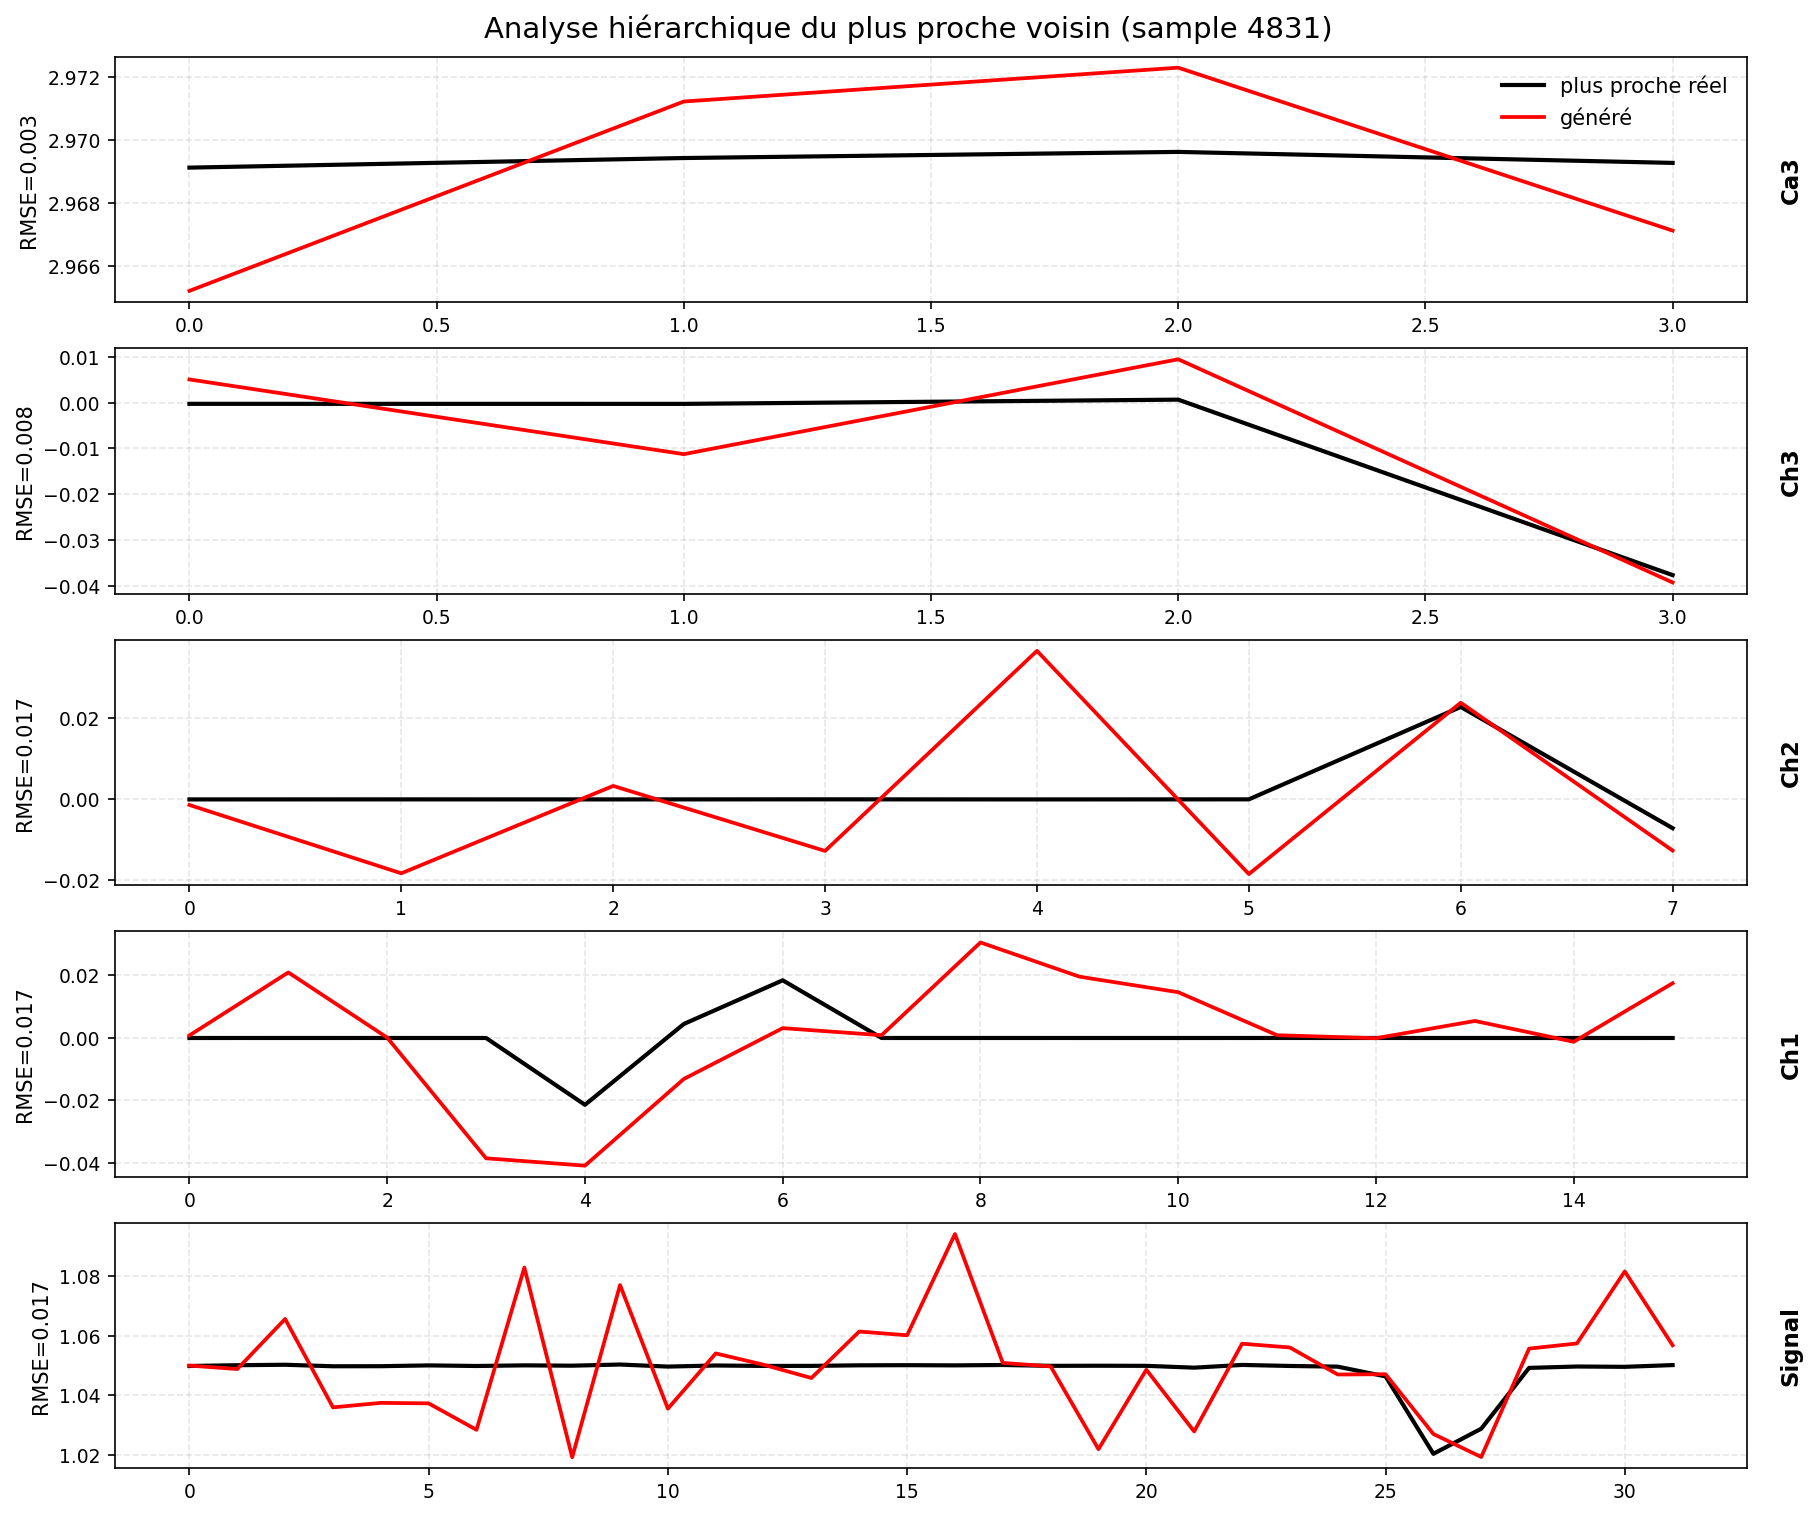

In [18]:
def plot_hierarchy_nearest_neighbor(
    generated,
    dataset,
    Ca3,
    Ch3,
    Ch2,
    Ch1,
    sample_idx=0,
):
    levels = [
        ("Ca3", generated["Ca3"], Ca3),
        ("Ch3", generated["Ch3"], Ch3),
        ("Ch2", generated["Ch2"], Ch2),
        ("Ch1", generated["Ch1"], Ch1),
        ("Signal", generated["signals"], dataset),
    ]

    fig, axes = plt.subplots(
        len(levels),
        1,
        figsize=(12, 10),
        constrained_layout=True,
    )

    for axis, (name, generated_block, real_block) in zip(axes, levels):

        generated_sample = generated_block[sample_idx]

        distances = torch.mean(
            (real_block - generated_sample[None, :]) ** 2,
            dim=1,
        )

        nearest_idx = torch.argmin(distances)

        nearest_real = real_block[nearest_idx]

        rmse = torch.sqrt(distances[nearest_idx]).item()

        x = torch.arange(len(generated_sample))

        axis.plot(
            x,
            nearest_real,
            color="black",
            linewidth=2,
            label="plus proche réel",
        )

        axis.plot(
            x,
            generated_sample,
            color="red",
            linewidth=1.8,
            label="généré",
        )

        axis.set_ylabel(
            f"RMSE={rmse:.3f}"
        )

        axis.text(
            1.02,
            0.5,
            name,
            transform=axis.transAxes,
            rotation=90,
            va="center",
            ha="left",
            fontsize=11,
            fontweight="bold",
        )

        axis.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

    axes[0].legend(frameon=False)

    fig.suptitle(
        f"Analyse hiérarchique du plus proche voisin (sample {sample_idx})",
        fontsize=14,
    )

    plt.show()


random_sample_idx = np.random.randint(0, generated_signals.shape[0])

plot_hierarchy_nearest_neighbor(
    generated,
    dataset,
    Ca3,
    Ch3,
    Ch2,
    Ch1,
    random_sample_idx
)